In [134]:
import numpy as np
import pickle
import json
import os
from pathlib import Path
import torch

DATA_DIR = Path("/global/cfs/cdirs/m3246/gregork")
CKPT_DIR = Path("/global/cfs/cdirs/m3246/gregork/checkpoints")

# playlists = ["1A", "1B", "1E", "1M", "1P", "1D", "1L", "1G", "1O", "1C", "1F", "1A", "1N"]
playlists = ["1A"]

# To evaluate:
# - energy regression: CONT_max_blob_and_prong_log_1A_20260205_031125, CONT_max_blob_and_prong_log_PretrainedSmall_1A_20260205_031322
# - CC (current classification): cont_classification_current_type_1A_20260204_013605, CONT_classification_current_type_Pretrained_1A_20260203_202002
# - EC (event classification): cont_classification_event_type_1A_20260204_013827, CONT_classification_event_type_Pretrained_1A_20260203_201240

"""
# Eval 29 February 2026

omnilearned evaluate -i $CKPT_DIR/current_type_1A_20260217_175547
omnilearned evaluate -i $CKPT_DIR/current_type_1A_20260218_015241
omnilearned evaluate -i $CKPT_DIR/pions_1A_20260218_014607
omnilearned evaluate -i $CKPT_DIR/pions_1A_20260218_014329
omnilearned evaluate -i $CKPT_DIR/E_avail_no_muon_1A_20260218_064743 --num-workers 2 --batch 100
omnilearned evaluate -i $CKPT_DIR/E_avail_1A_20260218_064634 --num-workers 2 --batch 100
omnilearned evaluate -i $CKPT_DIR/E_avail_1A_20260218_064356 --num-workers 2 --batch 100
omnilearned evaluate -i $CKPT_DIR/E_avail_no_muon_1A_20260218_064440 --num-workers 2 --batch 100
export CKPT_DIR=/global/cfs/cdirs/m3246/gregork/checkpoints


omnilearned evaluate -i $CKPT_DIR/E_avail_no_muon_linear_Huber_1A_20260222_223459 --num-workers 2 --batch 100
omnilearned evaluate -i $CKPT_DIR/E_avail_no_muon_linear_Huber_1A_20260222_232556 --num-workers 2 --batch 100

"""

training_names = {
  "cc": { # Current classification
    "1A_Transformer": "Train_CurrentType_20260217_073440",
    "1A_Transformer_2": "Train_CurrentType_20260217_072847",
    "1A_OmniLearnedS_FT": "current_type_1A_20260217_175547",
    "1A_OmniLearnedS": "current_type_1A_20260218_015241"
  },
  "E_avail_regression": {
    "1A_Transformer": "Train_Regress_E_available3_20260217_073551",
    "1A_Transformer_2": "Train_Regress_E_available3_20260217_072850",
    "1A_OmniLearnedS_FT": "E_avail_1A_20260218_064356",
    "1A_OmniLearnedS": "E_avail_1A_20260218_064634"
  },
  "Pi_classification": {
    "1A_Transformer": "Train_CC1orNPi_20260217_073415",
    "1A_Transformer_2": "Train_CC1orNPi_20260217_072842",
    "1A_OmniLearnedS_FT": "pions_1A_20260218_014329",
    "1A_OmniLearnedS": "pions_1A_20260218_014607"
  },
  "E_available_regression_no_muon": {
    "Tr_Log_MSE": "Train_Regress_E_available3_no_muon_20260218_000924",
    "Tr_Log_MSE_2": "Train_Regress_E_available3_no_muon_20260218_000722",
    "OS_Log_MSE_PT": "E_avail_no_muon_1A_20260218_064440",
    "Tr_MSE": "Train_Regress_E_available3_no_muon_Linear_20260220_225855",
    "Tr_HuberLoss": "Train_Regress_E_available3_no_muon_Linear_HuberLoss_20260221_033035",
    "Tr_HuberLoss_Weighted": "Train_Regress_E_available3_no_muon_Linear_HuberLoss_Weighted_20260221_033254",
    "Tr_HuberLoss_CutAnomalies": "debug_20260222_220755",
    "OS_Huber_Log": "E_avail_no_muon_linear_Huber_1A_20260222_232556",
    "OS_Huber_Log_PT": "E_avail_no_muon_linear_Huber_1A_20260222_223459",
    "OS_Huber": "E_avail_no_muon_Linear_Huber2_1A_20260223_193233",
    "OS_Huber_PT": "E_avail_no_muon_Linear_Huber2_1A_20260223_193110"
  }
}


In [135]:
results = {}
configs = {}
regression_tasks = ["E_avail_regression", "E_available_regression_no_muon"] # for those, exponentiate the pid and prediction
for key in training_names.keys():
    results[key] = {}
    configs[key] = {}
    for model in training_names[key]:
        # File looks like this: CKPT_DIR/training_name/outputs_cont_classification_current_type_<PLAYLIST>_20260204_013605_minerva_<PLAYLIST>_0.npz
        results[key][model] = {}
        configs[key][model] = {}
        for playlist in playlists:
            path1 = CKPT_DIR / training_names[key][model] / "test_results" / f"outputs_{training_names[key][model]}_minerva_{playlist}_0.npz"
            path2 = CKPT_DIR / training_names[key][model] / "test_results" / f"outputs_best_model_minerva_{playlist}_0.npz"
            if path1.exists():
                results[key][model][playlist] = dict(np.load(path1))
            elif path2.exists():
                results[key][model][playlist] = dict(np.load(path2))
            else:
                raise ValueError(f"No results found for {training_names[key][model]} on playlist {playlist} - {path1} and {path2} do not exist")
            if regression_tasks:
                if "log" in model.lower():
                    results[key][model][playlist]["pid"] = np.exp(results[key][model][playlist]["pid"])
                    results[key][model][playlist]["prediction"] = np.exp(results[key][model][playlist]["prediction"])
                    # Now, do the same for the linear model
                # set negative predictions to 0
                results[key][model][playlist]["prediction"][results[key][model][playlist]["prediction"] < 0] = 0
            settings_path = CKPT_DIR / training_names[key][model] / "settings.json"
            if settings_path.exists():
                configs[key][model][playlist] = json.load(open(settings_path, "rb"))
            else:
                print(f"No settings found for {training_names[key][model]} on playlist {playlist}")
                configs[key][model][playlist] = {}


No settings found for Train_CurrentType_20260217_073440 on playlist 1A
No settings found for Train_CurrentType_20260217_072847 on playlist 1A
No settings found for Train_Regress_E_available3_20260217_073551 on playlist 1A
No settings found for Train_Regress_E_available3_20260217_072850 on playlist 1A


No settings found for Train_CC1orNPi_20260217_073415 on playlist 1A
No settings found for Train_CC1orNPi_20260217_072842 on playlist 1A
No settings found for Train_Regress_E_available3_no_muon_20260218_000924 on playlist 1A
No settings found for Train_Regress_E_available3_no_muon_20260218_000722 on playlist 1A
No settings found for Train_Regress_E_available3_no_muon_Linear_20260220_225855 on playlist 1A
No settings found for Train_Regress_E_available3_no_muon_Linear_HuberLoss_20260221_033035 on playlist 1A
No settings found for Train_Regress_E_available3_no_muon_Linear_HuberLoss_Weighted_20260221_033254 on playlist 1A
No settings found for debug_20260222_220755 on playlist 1A


In [136]:
data_paths = {}
for key in training_names.keys():
    data_paths[key] = {}
    for model in training_names[key]:
        data_paths[key][model] = {}
        for playlist in playlists:
            data_paths[key][model][playlist] = {}
            #models[key][model][playlist]["settings"] = configs[key][model][playlist]
            model_path = CKPT_DIR / training_names[key][model] / "best_model.pt"
            if os.path.exists(model_path):
                data_paths[key][model][playlist] = torch.load(model_path, weights_only=False, map_location=torch.device("cpu"))["args"]["data_path"]
            else:
                print(f"No best model found for {training_names[key][model]} on playlist {playlist}")
                del data_paths[key][model][playlist]

No best model found for current_type_1A_20260217_175547 on playlist 1A
No best model found for current_type_1A_20260218_015241 on playlist 1A
No best model found for E_avail_1A_20260218_064356 on playlist 1A
No best model found for E_avail_1A_20260218_064634 on playlist 1A
No best model found for pions_1A_20260218_014329 on playlist 1A
No best model found for pions_1A_20260218_014607 on playlist 1A
No best model found for E_avail_no_muon_1A_20260218_064440 on playlist 1A
No best model found for E_avail_no_muon_linear_Huber_1A_20260222_232556 on playlist 1A
No best model found for E_avail_no_muon_linear_Huber_1A_20260222_223459 on playlist 1A
No best model found for E_avail_no_muon_Linear_Huber2_1A_20260223_193233 on playlist 1A
No best model found for E_avail_no_muon_Linear_Huber2_1A_20260223_193110 on playlist 1A


In [137]:
truth_labels = {}
for key in data_paths.keys():
    truth_labels[key] = {}
    for model in data_paths[key].keys():
        truth_labels[key][model] = {}
        for playlist in data_paths[key][model].keys():
            truth_labels[key][model][playlist] = torch.load(open(Path(data_paths[key][model][playlist]) /  playlist / "test" / "0.pb", "rb"), weights_only=False, map_location=torch.device("cpu"))["truth_labels"]

### Energy regression

In [138]:
E_true_dict, E_pred_dict = {}, {}  # Eval. dataset -> model -> E_true, E_pred, E_pred_over_true mapping
E_pred_over_true_dict = {}

regression_task = "E_available_regression_no_muon"

for model in results[regression_task].keys():
    for eval_dataset in results[regression_task][model].keys():
        E_true = results[regression_task][model][eval_dataset]["pid"]
        E_pred = results[regression_task][model][eval_dataset]["prediction"].flatten() 
        E_pred_over_true = E_pred / E_true
        if eval_dataset not in E_true_dict:
            E_true_dict[eval_dataset] = {}
            E_pred_dict[eval_dataset] = {}
            E_pred_over_true_dict[eval_dataset] = {}
        E_true_dict[eval_dataset][model] = E_true
        E_pred_dict[eval_dataset][model] = E_pred
        E_pred_over_true_dict[eval_dataset][model] = E_pred_over_true



/tmp/ipykernel_1365630/1941546027.py:10: RuntimeWarning: divide by zero encountered in divide
  E_pred_over_true = E_pred / E_true
/tmp/ipykernel_1365630/1941546027.py:10: RuntimeWarning: invalid value encountered in divide
  E_pred_over_true = E_pred / E_true


In [139]:
def get_Enu_fig(mc_E, reco_e_dict: dict):
    # reco_e_dict: key should be what's plotted. value should be same shape as mc_E, if it's not reconstructed, it should have value -1.
    # fig should have 2 x 2 subplots. left: counts; right: normalized histograms to unit area.
    # Top: E / 1000 histograms (GeV); Bottom: E_reco/E_mc
    import numpy as np
    import matplotlib.pyplot as plt
    # make the font of legend a bit smaller

    
    fig, ax = plt.subplots(2, 2, figsize=(12, 12))
    bins_E = np.linspace(0, 50, 300)
    bins_E_reco_over_true = np.linspace(0, 2, 100)
    ax[0, 0].hist(mc_E, bins=bins_E, histtype='step', color='black', label='MC E')
    ax[0, 1].hist(mc_E, bins=bins_E, histtype='step', color='black', label='MC E', density=True)
    
    for method in reco_e_dict.keys():
        mask = reco_e_dict[method] > 0
        percentage_reconstructed = round(np.sum(mask) / len(mask) * 100, 1)
        ax[0, 0].hist(reco_e_dict[method], bins=bins_E, histtype='step', label=method + f" ({percentage_reconstructed}%)")
        ax[0, 1].hist(reco_e_dict[method], bins=bins_E, histtype='step', label=method + f" ({percentage_reconstructed}%)", density=True)
        E_reco_over_true = reco_e_dict[method][mask] / mc_E[mask]
        # MPV (Most Probable Value) - use the bin with max count
        counts, bin_edges = np.histogram(E_reco_over_true, bins=bins_E_reco_over_true)
        mpv_idx = np.argmax(counts)
        mpv = (bin_edges[mpv_idx] + bin_edges[mpv_idx + 1]) / 2
        # Calculate RMS from MPV
        # rms = np.sqrt(np.mean((E_reco_over_true - mpv)**2)) # compute rms from the values bounded by [0, 2]
        mask = (E_reco_over_true >= 0) & (E_reco_over_true <= 2)
        rms = np.sqrt(np.mean((E_reco_over_true[mask] - mpv)**2))
        bottom_label = f"{method} ({percentage_reconstructed}%, MPV={mpv:.3f}, RMS={rms:.3f})"
        ax[1, 0].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', label=bottom_label)
        ax[1, 1].hist(E_reco_over_true, bins=bins_E_reco_over_true, histtype='step', label=bottom_label, density=True)
    fontsize_legend = 6.5
    ax[0, 0].legend(fontsize=fontsize_legend, loc="lower left")
    ax[0, 0].set_xlabel("Energy [GeV]")
    ax[0, 0].set_ylabel("Counts")
    ax[0, 0].set_title("E nu Distribution")
    ax[0, 1].legend(fontsize=fontsize_legend, loc="lower left")
    ax[0, 1].set_xlabel("Energy [GeV]")
    ax[0, 1].set_ylabel("Relative counts")
    ax[0, 1].set_title("E nu Distribution (normalized)")
    ax[1, 0].legend(fontsize=fontsize_legend)
    ax[1, 0].set_xlabel("E reco / E true")
    ax[1, 0].set_ylabel("Counts")
    ax[1, 0].set_title("E reco / E true Distribution")
    ax[1, 1].legend(fontsize=fontsize_legend, loc="lower left")
    ax[1, 1].set_xlabel("E reco / E true")
    ax[1, 1].set_ylabel("Relative counts")
    ax[1, 1].set_title("E reco / E true Distribution (normalized)")
    

    
    # Put a grid on all
    ax[0, 0].grid(True)
    ax[0, 1].grid(True)
    ax[0, 1].set_yscale("log")
    ax[1, 0].grid(True)
    ax[1, 1].grid(True)

    # Keep all legends in a consistent position.
    ax[0, 0].legend(loc='lower left', fontsize=fontsize_legend)
    ax[0, 1].legend(loc='lower left', fontsize=fontsize_legend)
    ax[1, 0].legend(loc='lower left', fontsize=fontsize_legend)
    ax[1, 1].legend(loc='lower left', fontsize=fontsize_legend)
    fig.tight_layout()
    return fig


In [140]:
Enu_baselines = {}
Enu_filters = {}
mc_E = {}
model = "Tr_Log_MSE"
for eval_dataset in configs[regression_task][model]:
    if eval_dataset not in Enu_baselines:
        Enu_baselines[eval_dataset] = {}
        Enu_filters[eval_dataset] = {}
    settings = configs[regression_task][model][eval_dataset]
    if "path" not in settings:
        settings["path"] = data_paths[regression_task][model][eval_dataset]
    split_idx = os.path.join(settings["path"], "result.pkl")
    split_idx = pickle.load(open(split_idx, "rb"))
    current_baselines = os.path.join(settings["path"], "baselines", f"{eval_dataset}_enu_baselines.npz")
    current_baselines = np.load(current_baselines, mmap_mode="r")
    #mc_E[eval_dataset] = #np.array(E_recoil_no_muon) #truth_labels["E_recoil_only"][split_idx[eval_dataset]["test_idx"]] / 1000
    mc_E[eval_dataset] = E_true_dict[eval_dataset][model]
    for key in current_baselines.keys():
        if key in ["muon_filter_CC_paper", "q0", "q3"]:
            Enu_filters[eval_dataset][key] = current_baselines[key][split_idx[eval_dataset]["test_idx"]]
            if key in ["q0", "q3"]:
                # divide by 1000
                Enu_filters[eval_dataset][key] = Enu_filters[eval_dataset][key] / 1000
        elif key in ["E_recoil_CCinc_only"]:
            idx_mask = split_idx[eval_dataset]["test_idx"]
            Enu_baselines[eval_dataset][key] = current_baselines[key][split_idx[eval_dataset]["test_idx"]] / 1000
            # now set the 0s to -1
            Enu_baselines[eval_dataset][key][Enu_baselines[eval_dataset][key] == 0] = -1


In [142]:
models_to_plot = ["Tr_Log_MSE", "OS_Log_MSE_PT", "Tr_MSE", "Tr_HuberLoss", "Tr_HuberLoss_Weighted", "Tr_HuberLoss_CutAnomalies", "OS_Huber_Log", "OS_Huber_Log_PT", "OS_Huber", "OS_Huber_PT",]
dataset_to_plot = "1A"

dict_model_E_reco = {key: E_pred_dict[dataset_to_plot][key] for key in models_to_plot}
dict_baselines_E_reco = Enu_baselines[dataset_to_plot]
for key in  dict_baselines_E_reco:
    dict_model_E_reco[key] = dict_baselines_E_reco[key]
#get_Enu_fig(mc_E[dataset_to_plot], dict_model_E_reco).show()


In [143]:
def get_baseline_and_models_E_filtered(E_true, baseline_E_reco, baseline_name, model_E_reco_dict):
    mask = baseline_E_reco >= 0
    baseline_E_reco = baseline_E_reco[mask]
    E_true = E_true[mask]
    output_dict = {}
    output_dict[baseline_name] = baseline_E_reco
    for model_name in model_E_reco_dict.keys():
        output_dict[model_name] = model_E_reco_dict[model_name][mask]
    return E_true, output_dict, mask


In [144]:
mc_E_filtered, methods_filtered, mask1 = get_baseline_and_models_E_filtered(mc_E[dataset_to_plot], dict_baselines_E_reco["E_recoil_CCinc_only"], "E_recoil_CCinc_only", dict_model_E_reco)
#get_Enu_fig(mc_E_filtered, methods_filtered).show()

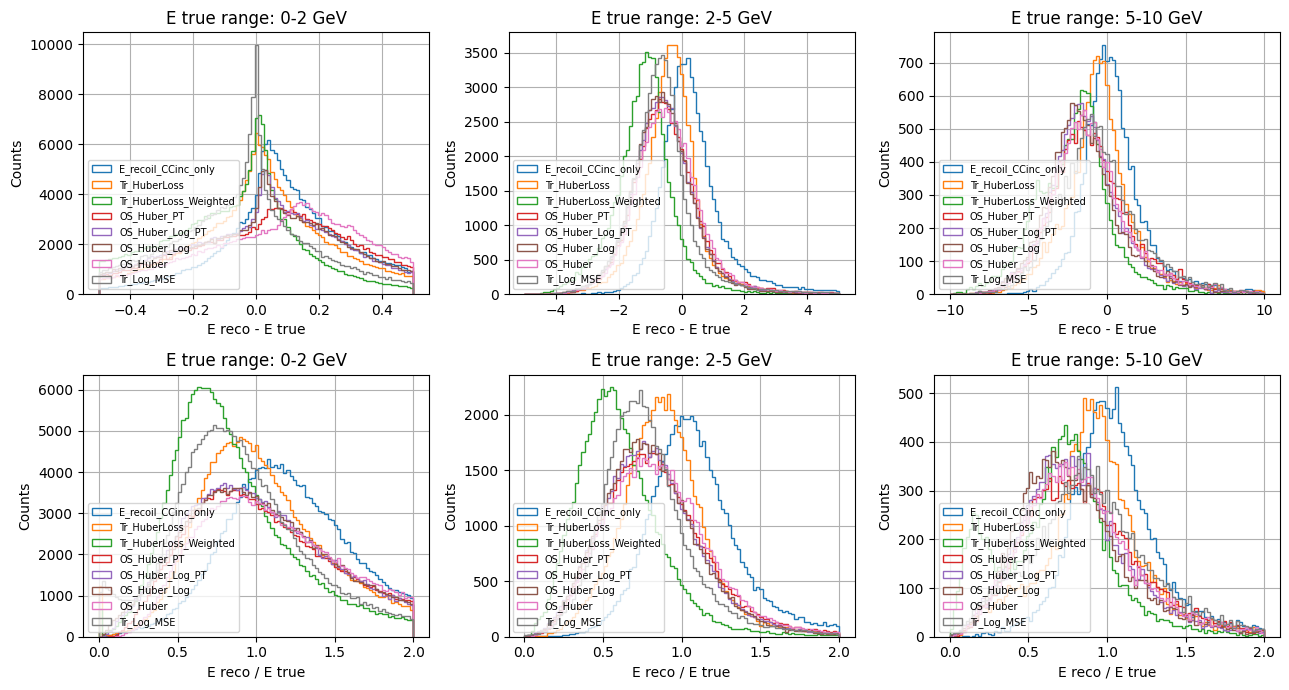

In [153]:
# For the same experiments, plot E reco - E true on three plots, for e true ranges [0, 2], [2, 5], [5, 10], [10+]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 3, figsize=(13, 7))

labels = ["E_recoil_CCinc_only", "Tr_HuberLoss", "Tr_HuberLoss_Weighted", "OS_Huber_PT", "OS_Huber_Log_PT", "OS_Huber_Log", "OS_Huber", "Tr_Log_MSE"]
residual_bins = [np.linspace(-0.5, 0.5, 100), np.linspace(-5, 5, 100), np.linspace(-10, 10, 100)]
ratio_bins = [np.linspace(0, 2, 100), np.linspace(0, 2, 100), np.linspace(0, 2, 100)]
mask_filter = Enu_filters["1A"]["muon_filter_CC_paper"][mask1]
for i in range(3):
    mask = (mc_E_filtered > [0, 2, 5, 10][i]) & (mc_E_filtered < [2, 5, 10, 100][i])
    mask = mask & mask_filter
    for label in labels:
        reco = methods_filtered[label][mask]
        true = mc_E_filtered[mask]
        reco_minus_true = reco - true
        ax[0, i].hist(reco_minus_true, bins=residual_bins[i], histtype="step", label=label)
        valid_ratio = true > 0
        reco_over_true = reco[valid_ratio] / true[valid_ratio]
        ax[1, i].hist(reco_over_true, bins=ratio_bins[i], histtype="step", label=label)

    ax[0, i].legend(loc="lower left", fontsize=7)
    ax[0, i].grid()
    ax[0, i].set_xlabel("E reco - E true")
    ax[0, i].set_ylabel("Counts")
    ax[0, i].set_title(f"E true range: {['0-2', '2-5', '5-10', '10+'][i]} GeV")

    ax[1, i].legend(loc="lower left", fontsize=7)
    ax[1, i].grid()
    ax[1, i].set_xlabel("E reco / E true")
    ax[1, i].set_ylabel("Counts")
    ax[1, i].set_title(f"E true range: {['0-2', '2-5', '5-10', '10+'][i]} GeV")

fig.tight_layout()


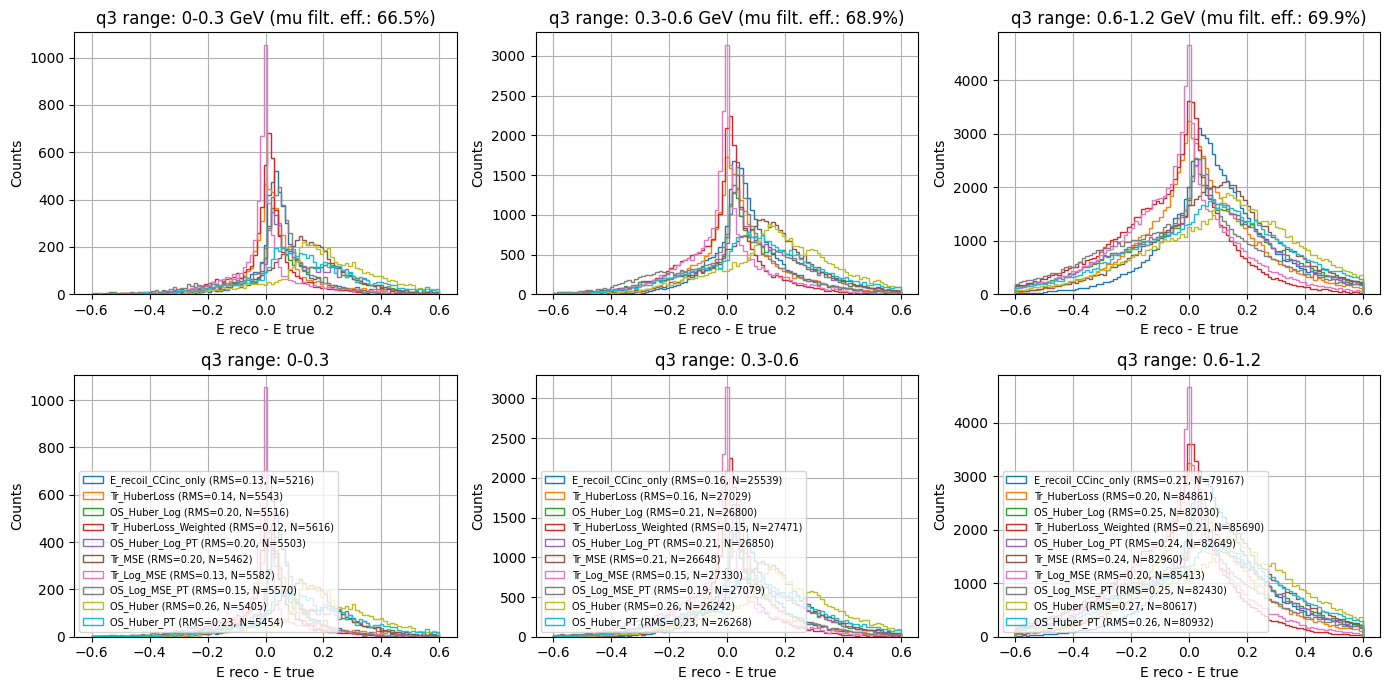

In [146]:
# For the same experiments, plot E reco - E true on three plots, for e true ranges [0, 2], [2, 5], [5, 10], [10+]
import matplotlib.pyplot as plt
from mpmath.libmp.libmpi import mpi_overlap
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
labels = ["E_recoil_CCinc_only", "Tr_HuberLoss", "OS_Huber_Log", "Tr_HuberLoss_Weighted", "OS_Huber_Log_PT", "Tr_MSE", "Tr_Log_MSE", "OS_Log_MSE_PT", "OS_Huber", "OS_Huber_PT"]

# Do a MC q3 filter. 0 to 0.3, 0.3 to 0.6, 0.6 to 1.2

filter_CCinc = dict_model_E_reco["E_recoil_CCinc_only"] >= 0

q3 = Enu_filters["1A"]["q3"]
for i in range(3):
    mask_original = (q3 > [0, 0.3, 0.6][i]) & (q3 <= [0.3, 0.6, 1.2][i])
    mask = mask_original & Enu_filters["1A"]["muon_filter_CC_paper"]
    bins = [np.linspace(-.6, .6, 100), np.linspace(-.6, .6, 100), np.linspace(-.6, .6, 100)]
    mask = mask & filter_CCinc

    for label in labels:
        efficiency = mask.sum() / mask_original.sum() * 100
        reco_minus_true = dict_model_E_reco[label][mask]-mc_E[dataset_to_plot][mask]
        rms = np.sqrt(np.mean((reco_minus_true[np.abs(reco_minus_true) < 0.6])**2))
        N_events_in_histogram = np.sum(np.abs(reco_minus_true) < 0.6)
        ax[0, i].hist(reco_minus_true, bins=bins[i], histtype="step", label=label + f" (RMS={rms:.2f}, N={N_events_in_histogram})")
        ax[1, i].hist(reco_minus_true, bins=bins[i], histtype="step", label=label + f" (RMS={rms:.2f}, N={N_events_in_histogram})")

    #ax[0, i].legend(loc="lower left", fontsize=7)
    ax[0, i].grid()
    ax[0, i].set_xlabel("E reco - E true")
    ax[0, i].set_ylabel("Counts")
    ax[0, i].set_title(f"q3 range: {['0-0.3', '0.3-0.6', '0.6-1.2'][i]} GeV (mu filt. eff.: {efficiency:.1f}%)")
    ax[1, i].legend(loc="lower left", fontsize=7)
    ax[1, i].grid()
    ax[1, i].set_xlabel("E reco - E true")
    ax[1, i].set_ylabel("Counts")
    ax[1, i].set_title(f"q3 range: {['0-0.3', '0.3-0.6', '0.6-1.2'][i]}")
fig.tight_layout()

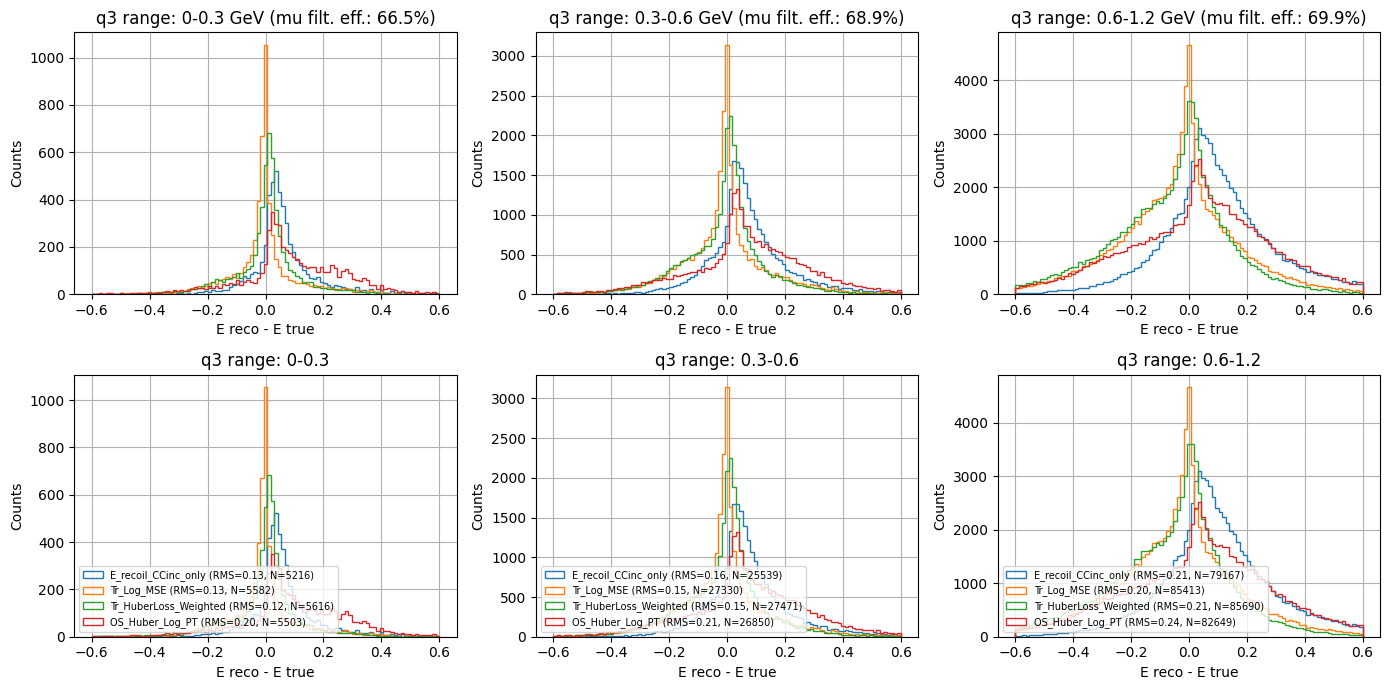

In [150]:
# For the same experiments, plot E reco - E true on three plots, for e true ranges [0, 2], [2, 5], [5, 10], [10+]
import matplotlib.pyplot as plt
from mpmath.libmp.libmpi import mpi_overlap
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
labels = ["E_recoil_CCinc_only", "Tr_Log_MSE", "Tr_HuberLoss_Weighted", "OS_Huber_Log_PT"]

# Do a MC q3 filter. 0 to 0.3, 0.3 to 0.6, 0.6 to 1.2

filter_CCinc = dict_model_E_reco["E_recoil_CCinc_only"] >= 0

q3 = Enu_filters["1A"]["q3"]
for i in range(3):
    mask_original = (q3 > [0, 0.3, 0.6][i]) & (q3 <= [0.3, 0.6, 1.2][i])
    mask = mask_original & Enu_filters["1A"]["muon_filter_CC_paper"]
    bins = [np.linspace(-.6, .6, 100), np.linspace(-.6, .6, 100), np.linspace(-.6, .6, 100)]
    mask = mask & filter_CCinc

    for label in labels:
        efficiency = mask.sum() / mask_original.sum() * 100
        reco_minus_true = dict_model_E_reco[label][mask]-mc_E[dataset_to_plot][mask]
        rms = np.sqrt(np.mean((reco_minus_true[np.abs(reco_minus_true) < 0.6])**2))
        N_events_in_histogram = np.sum(np.abs(reco_minus_true) < 0.6)
        ax[0, i].hist(reco_minus_true, bins=bins[i], histtype="step", label=label + f" (RMS={rms:.2f}, N={N_events_in_histogram})")
        ax[1, i].hist(reco_minus_true, bins=bins[i], histtype="step", label=label + f" (RMS={rms:.2f}, N={N_events_in_histogram})")

    #ax[0, i].legend(loc="lower left", fontsize=7)
    ax[0, i].grid()
    ax[0, i].set_xlabel("E reco - E true")
    ax[0, i].set_ylabel("Counts")
    ax[0, i].set_title(f"q3 range: {['0-0.3', '0.3-0.6', '0.6-1.2'][i]} GeV (mu filt. eff.: {efficiency:.1f}%)")
    ax[1, i].legend(loc="lower left", fontsize=7)
    ax[1, i].grid()
    ax[1, i].set_xlabel("E reco - E true")
    ax[1, i].set_ylabel("Counts")
    ax[1, i].set_title(f"q3 range: {['0-0.3', '0.3-0.6', '0.6-1.2'][i]}")
fig.tight_layout()

### Classification tasks: binary (event current: CC or NC); multiclass (event type)

In [50]:
model_to_plot = "1A_Transformer"
datasets = results["cc"][model_to_plot].keys()
labels_current_type = ["CC", "NC"]
#labels_event_type = ["CCQE", "RES", "DIS", "Coherent", "2p2h"]
labels_event_type = ["CC1PiPlus", "CC1PiMinus", "CCNPi", "Other"]
len(datasets)

1

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix_on_ax(ax, y_true, y_pred, class_names):
    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    #ax.set_title("Confusion Matrix")
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)


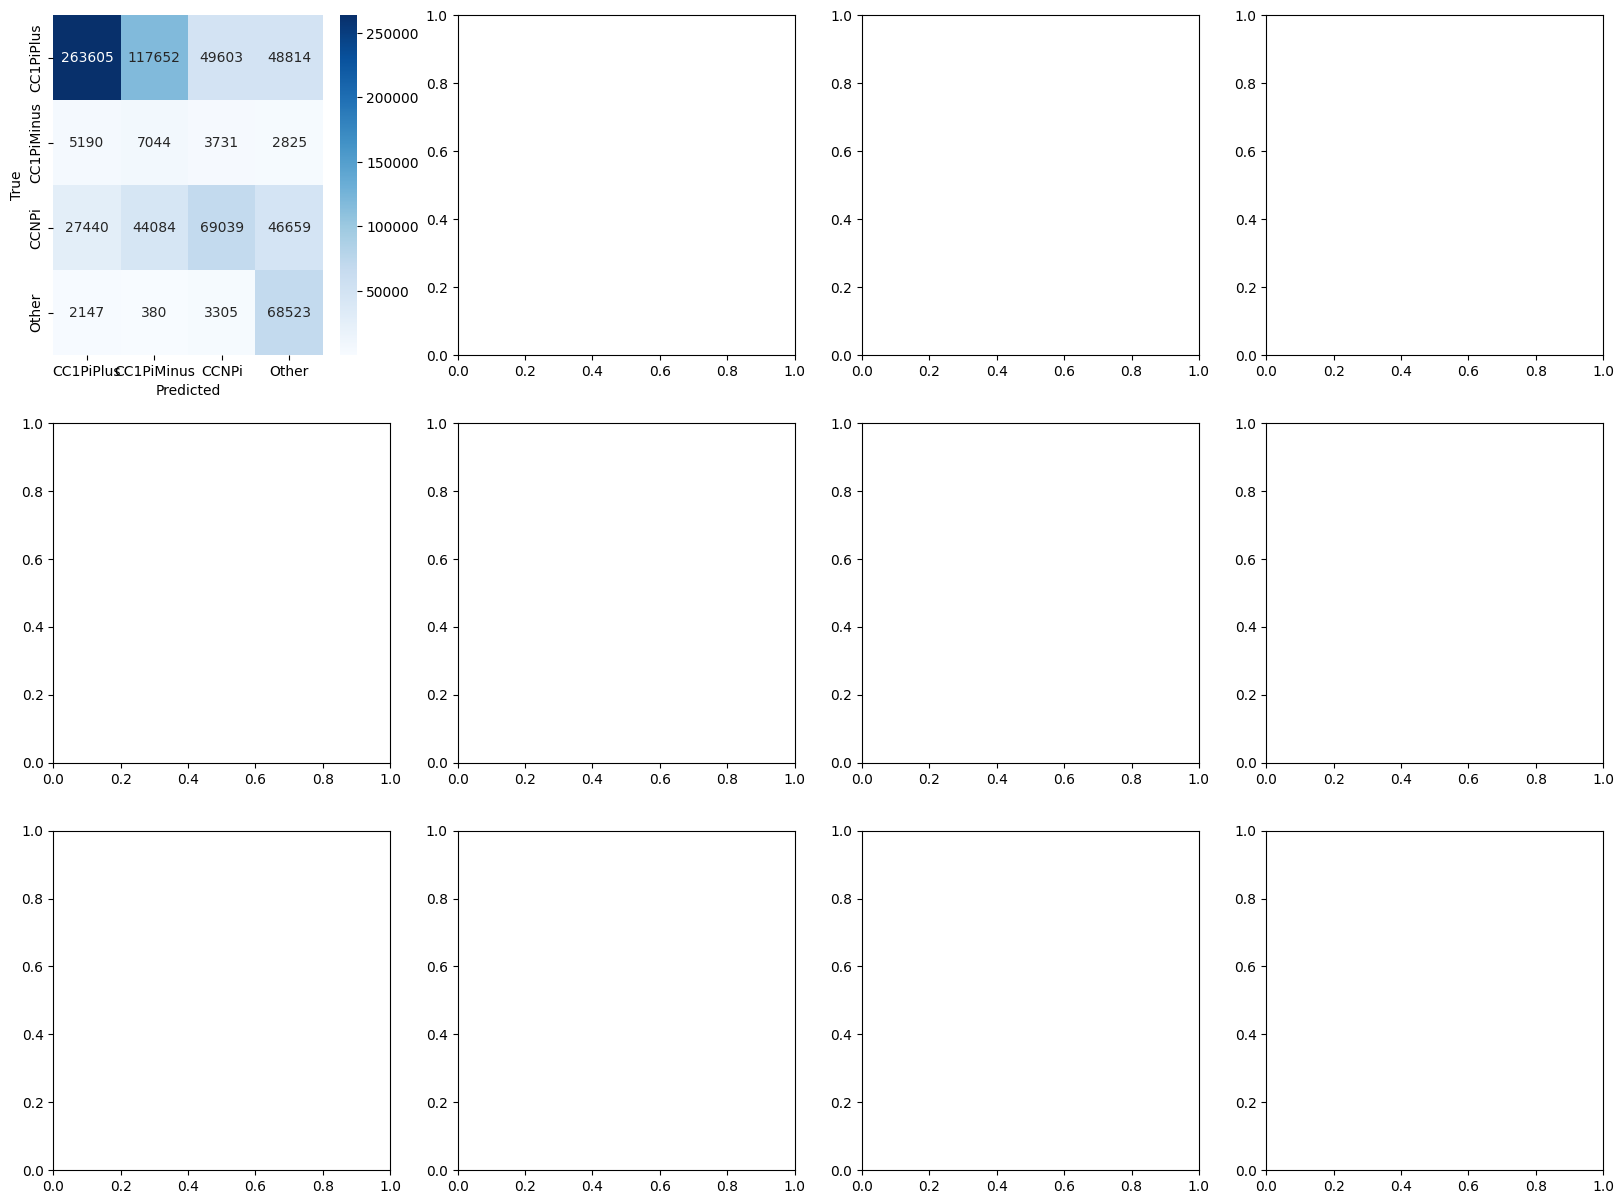

In [52]:
# 12 datasets: Make a 3x4 grid of confusion matrices
fig, ax = plt.subplots(3, 4, figsize=(20, 15))
for i, dataset in enumerate(datasets):
    plot_confusion_matrix_on_ax(ax[i // 4, i % 4], results["Pi_classification"][model_to_plot][dataset]["pid"], results["Pi_classification"][model_to_plot][dataset]["prediction"].argmax(axis=1), labels_event_type)
fig.show()


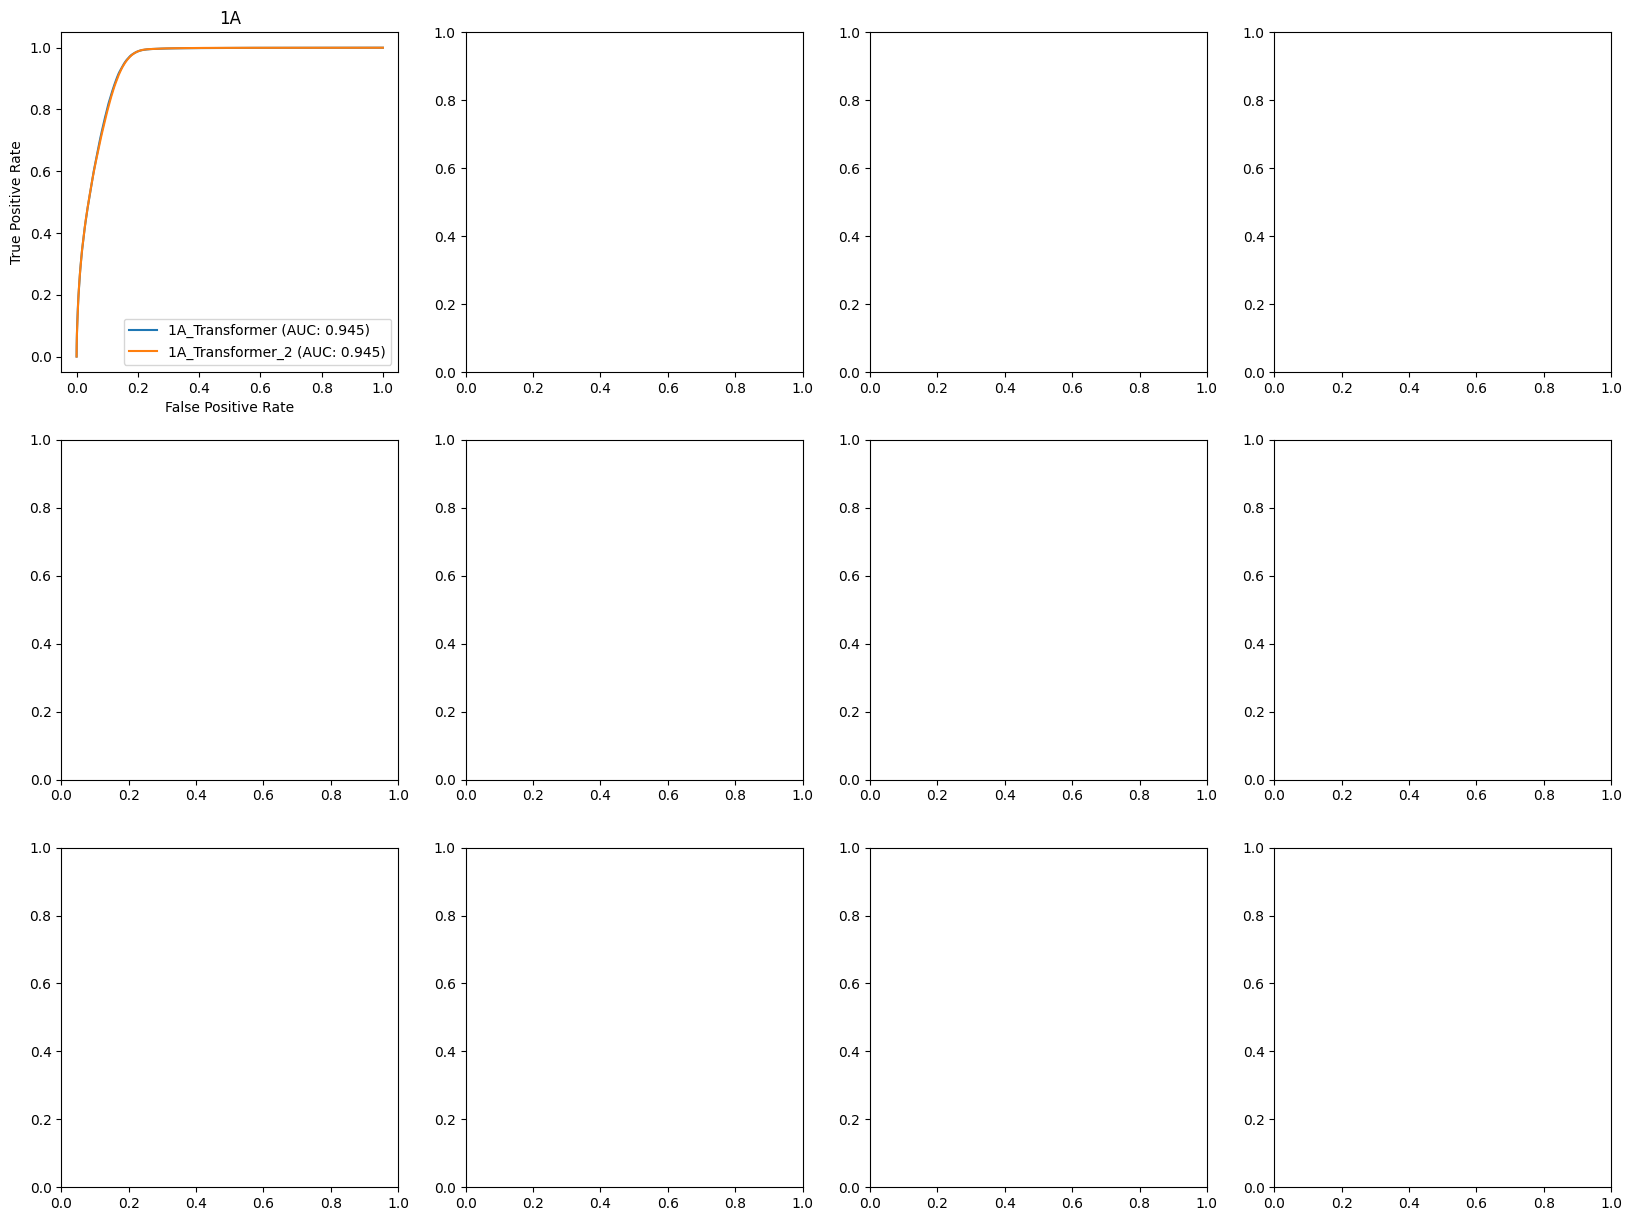

In [45]:
# now make a similar plot but of roc curves for binary classification (CC/NC)
from sklearn.metrics import roc_curve, auc

def plot_roc_curve_on_ax(ax, y_true, y_pred, class_names, label=None):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    auc_score = auc(fpr, tpr)
    if label:
        label = label + f" (AUC: {auc_score:.3f})"
    ax.plot(fpr, tpr, label=label)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    # also compute AUC and print it in a text box
    #ax.text(0.05, 0.95, f"AUC: {auc_score:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')
    #ax.legend()

# 12 datasets: Make a 3x4 grid of ROC curves
fig, ax = plt.subplots(3, 4, figsize=(20, 15))
for model_to_plot in ["1A_Transformer", "1A_Transformer_2"]:
    for i, dataset in enumerate(datasets):
        plot_roc_curve_on_ax(ax[i // 4, i % 4], results["cc"][model_to_plot][dataset]["pid"], results["cc"][model_to_plot][dataset]["prediction"][:, 1], labels_current_type, label=model_to_plot)
        # also plot the AUC metric on the top left of the plot
        # Turn on legend
        # NC is the positive class
        
for i, dataset in enumerate(datasets):
    ax[i // 4, i % 4].legend()
    ax[i // 4, i % 4].set_title(dataset)
    # Try doing log x and y scales
    #ax[i // 4, i % 4].set_xscale("log")
    #ax[i // 4, i % 4].set_yscale("log")
fig.show()


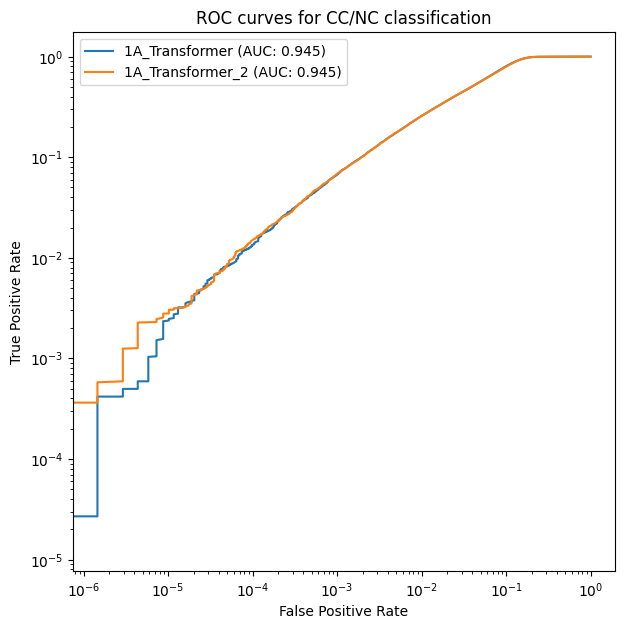

In [47]:
# just plot the 1A roc curve for different models
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
for model_to_plot in ["1A_Transformer", "1A_Transformer_2"]:
    plot_roc_curve_on_ax(ax, results["cc"][model_to_plot]["1A"]["pid"], results["cc"][model_to_plot]["1A"]["prediction"][:, 1], labels_current_type, label=model_to_plot)
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("ROC curves for CC/NC classification")
fig.show()


In [49]:
# Print the percentage of NC ground truth events in each dataset
for dataset in datasets:
    print(f"{dataset}: {np.sum(results['cc'][model_to_plot][dataset]['pid'] == 1) / len(results['cc'][model_to_plot][dataset]['pid'])}")


1A: 0.09783024863132384


In [56]:
np.unique(results["Pi_classification"]["1A_Transformer"]["1A"]["pid"], return_counts=True)

(array([0, 1, 2, 3]), array([479674,  18790, 187222,  74355]))

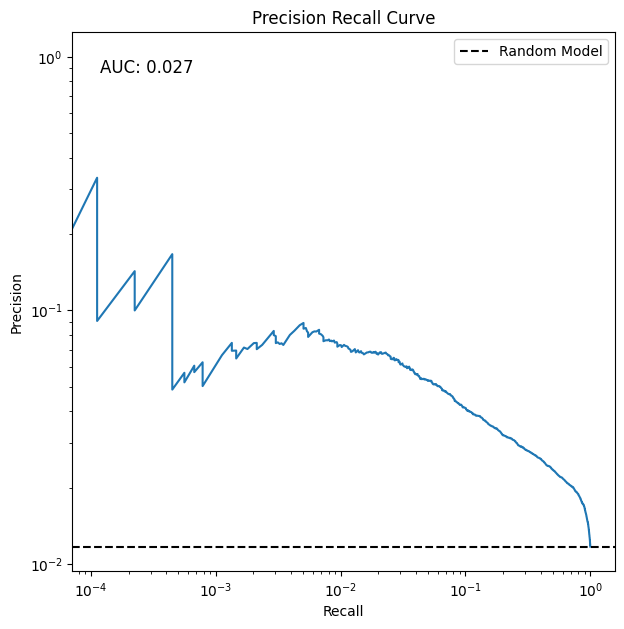

In [ ]:
# precision recall curve
from sklearn.metrics import precision_recall_curve



precision, recall, thresholds = precision_recall_curve(y_true, probs)
precision_random, recall_random, _ = precision_recall_curve(y_true, np.random.permutation(probs))
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.plot(recall, precision)
#ax.plot(recall_random, precision_random, color="black", linestyle="--", label="Random Model")
ax.axhline(y_true.mean(), color="black", linestyle="--", label="Random Model")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision Recall Curve")
ax.legend()
# compute area under the curve
auc_score = auc(recall, precision)
# plot curve for random model: horizontal line at y_true.mean
ax.text(0.05, 0.95, f"AUC: {auc_score:.3f}", transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')
fig.show()


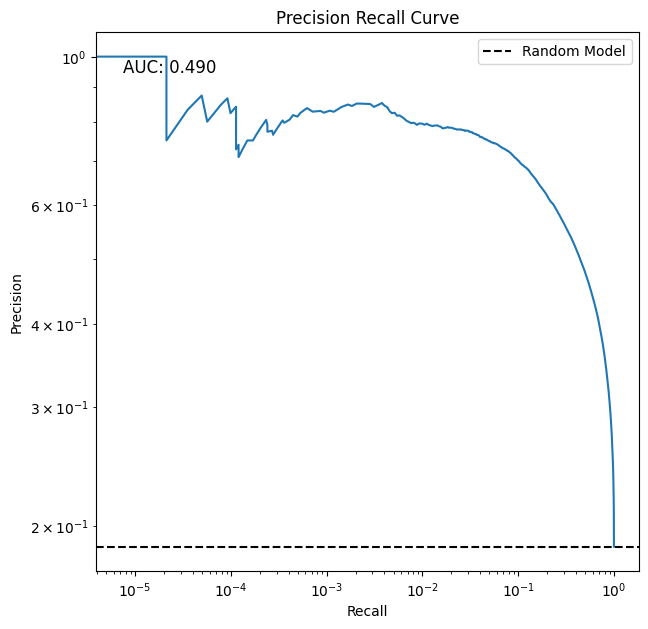

In [28]:
# make a precision recall curve
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, probs)
#precision_random, recall_random, _ = precision_recall_curve(y_true, np.random.permutation(probs))
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.plot(recall, precision)
#ax.plot(recall_random, precision_random, color="black", linestyle="--", label="Random Model")
# hline
ax.axhline(y_true.mean(), color="black", linestyle="--", label="Random Model")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision Recall Curve")
# compute area under the curve
auc_score = auc(recall, precision)
ax.text(0.05, 0.95, f"AUC: {auc_score:.3f}", transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')
fig.show()

In [29]:
test_dataset = "1A"
path = Path(settings["path"]) / "test" / f"{test_dataset}.pkl"


In [30]:
pion_four_vector_MC = truth_labels["1pi_classification"]["1A_Transformer"]["1A"][:, -4:]
pion_E_MC = pion_four_vector_MC[:, 0] / 1000.0

In [31]:
# Make an efficiency plot vs GT pion energy

y_true = results["1pi_classification"]["1A_Transformer"]["1A"]["pid"]
y_pred = results["1pi_classification"]["1A_Transformer"]["1A"]["prediction"].argmax(axis=1)

np.bincount(y_pred)
# Remove cases where y_true or y_pred is 1 (no CC1PiMinus events...)
mask = (y_true != 1) & (y_pred != 1)
y_true = y_true[mask]
y_pred = y_pred[mask]

# Also, rewrite y_true to be 0, 1 instead of 0, 2
np.bincount(y_pred)
y_true = y_true == 2
y_pred =  results["1pi_classification"]["1A_Transformer"]["1A"]["prediction"][:, [0, 2]]

# There are only 1% positive labels in the dataset.
logits = results["1pi_classification"]["1A_Transformer"]["1A"]["prediction"][:, [0, 2]]
# Do a softmax
probs = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
probs = probs[:, 1]


In [32]:
pion_E_MC_bins = np.array([0, 0.5, 0.75, 1.0, 2.0])
bin_middles = (pion_E_MC_bins[:-1] + pion_E_MC_bins[1:]) / 2
thresholds = np.linspace(0.5, 0.9, 10)
efficiency = {} # Threshold -> efficiency
purity = {} # Simply threshold -> Purity of the selected events (there is no pion mass involved)
for threshold in thresholds:
    efficiency[threshold] = []
    # Purity is percentage of selected events that have GT label 1
    mask = probs > threshold
    if mask.sum().item() > 0:
        purity[threshold] = y_true[mask].sum().item() / mask.sum().item()
    else:
        purity[threshold] = 0
    for i in range(len(pion_E_MC_bins) - 1):
        mask = (pion_E_MC > pion_E_MC_bins[i]) & (pion_E_MC <= pion_E_MC_bins[i+1])
        N_GT_pions = mask.sum().item()
        #print("N pions in bin", i, mask.sum().item())
        mask = mask & (probs > threshold)
        mask_sum = mask.sum().item()    
        if N_GT_pions > 0:
            efficiency[threshold].append(mask_sum / N_GT_pions)
        else:
            efficiency[threshold].append(0)


/tmp/ipykernel_599994/3569644144.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask = mask & (probs > threshold)


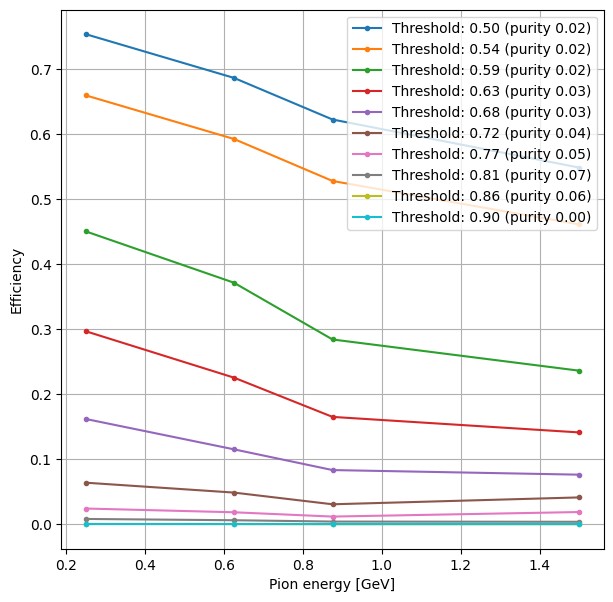

In [33]:
# Now, make a plot of pion energy (middle of bin) vs efficiency for each threshold
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
for threshold in thresholds:
    ax.plot(bin_middles, efficiency[threshold], ".-", label=f"Threshold: {threshold:.2f} (purity {purity[threshold]:.2f})")
ax.legend()
ax.set_xlabel("Pion energy [GeV]")
ax.set_ylabel("Efficiency")
ax.grid()

array([0.4995, 0.4277, 0.509 , ..., 0.3909, 0.255 , 0.3   ],
      shape=(760041,), dtype=float16)